In [ ]:
!pip install pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')



In [ ]:
df = pd.read_csv('/content/Unemployment in India.csv')
df.columns = df.columns.str.strip()   # remove leading/trailing spaces

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (768, 7)

Columns: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']

First 5 rows:


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [ ]:
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
print(df.describe())

=== Data Types ===
Region                                      object
Date                                        object
Frequency                                   object
Estimated Unemployment Rate (%)            float64
Estimated Employed                         float64
Estimated Labour Participation Rate (%)    float64
Area                                        object
dtype: object

=== Missing Values ===
Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

=== Basic Statistics ===
       Estimated Unemployment Rate (%)  Estimated Employed  \
count                       740.000000        7.400000e+02   
mean                         11.787946        7.204460e+06   
std                          10.721298 

In [ ]:
# Drop rows with any missing values
df = df.dropna()
print("Records after cleaning:", len(df))   # → 740

# Convert Date column (stored as string) to proper datetime
df['Date'] = pd.to_datetime(df['Date'].str.strip(), dayfirst=True)

# Sort by date
df = df.sort_values('Date').reset_index(drop=True)

# Extract useful time features
df['Year']      = df['Date'].dt.year
df['Month']     = df['Date'].dt.month
df['YearMonth'] = df['Date'].dt.to_period('M')

print("Date Range :", df['Date'].min().date(), "→", df['Date'].max().date())
print("States/UTs :", df['Region'].nunique())
print("Area Types :", df['Area'].unique().tolist())


Records after cleaning: 740
Date Range : 2019-05-31 → 2020-06-30
States/UTs : 28
Area Types : ['Rural', 'Urban']


In [ ]:
print("=" * 50)
print("       EXPLORATORY DATA ANALYSIS")
print("=" * 50)

print(f"\nAverage Unemployment Rate : {df['Estimated Unemployment Rate (%)'].mean():.2f}%")
print(f"Maximum Unemployment Rate : {df['Estimated Unemployment Rate (%)'].max():.2f}%")
print(f"Minimum Unemployment Rate : {df['Estimated Unemployment Rate (%)'].min():.2f}%")

print("\n=== Unemployment by Area ===")
print(df.groupby('Area')['Estimated Unemployment Rate (%)'].mean().round(2))

print("\n=== Top 5 Worst States (Overall Avg) ===")
print(df.groupby('Region')['Estimated Unemployment Rate (%)']
      .mean().sort_values(ascending=False).head().round(2))

print("\n=== Top 5 Best States (Overall Avg) ===")
print(df.groupby('Region')['Estimated Unemployment Rate (%)']
      .mean().sort_values().head().round(2))

# Define Covid periods
pre_covid  = df[df['Date'] < '2020-03-01']
covid_peak = df[(df['Date'] >= '2020-04-01') & (df['Date'] <= '2020-05-31')]
post_covid = df[df['Date'] >= '2020-06-01']

print("\n=== Covid-19 Period Comparison ===")
print(f"Pre-Covid  avg  (May 2019 – Feb 2020) : {pre_covid['Estimated Unemployment Rate (%)'].mean():.2f}%")
print(f"Covid Peak avg  (Apr 2020 – May 2020) : {covid_peak['Estimated Unemployment Rate (%)'].mean():.2f}%")
print(f"Post-Covid avg  (Jun 2020 onwards)    : {post_covid['Estimated Unemployment Rate (%)'].mean():.2f}%")

peak = df.loc[df['Estimated Unemployment Rate (%)'].idxmax()]
print(f"\n🔺 Highest Ever : {peak['Estimated Unemployment Rate (%)']:.2f}% "
      f"in {peak['Region']} ({peak['Date'].strftime('%B %Y')})")

       EXPLORATORY DATA ANALYSIS

Average Unemployment Rate : 11.79%
Maximum Unemployment Rate : 76.74%
Minimum Unemployment Rate : 0.00%

=== Unemployment by Area ===
Area
Rural    10.32
Urban    13.17
Name: Estimated Unemployment Rate (%), dtype: float64

=== Top 5 Worst States (Overall Avg) ===
Region
Tripura             28.35
Haryana             26.28
Jharkhand           20.58
Bihar               18.92
Himachal Pradesh    18.54
Name: Estimated Unemployment Rate (%), dtype: float64

=== Top 5 Best States (Overall Avg) ===
Region
Meghalaya      4.80
Odisha         5.66
Assam          6.43
Uttarakhand    6.58
Gujarat        6.66
Name: Estimated Unemployment Rate (%), dtype: float64

=== Covid-19 Period Comparison ===
Pre-Covid  avg  (May 2019 – Feb 2020) : 9.51%
Covid Peak avg  (Apr 2020 – May 2020) : 24.26%
Post-Covid avg  (Jun 2020 onwards)    : 11.90%

🔺 Highest Ever : 76.74% in Puducherry (April 2020)


In [ ]:
# Color palette
BLUE   = '#2563EB'
ORANGE = '#F97316'
RED    = '#EF4444'
GREEN  = '#10B981'
PURPLE = '#8B5CF6'
BG     = '#F8FAFC'

# Global plot style
plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.facecolor'    : BG,
    'figure.facecolor'  : 'white',
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'grid.color'        : '#CBD5E1',
})

# Covid lockdown window (for shading on charts)
covid_start = pd.Timestamp('2020-03-01')
covid_end   = pd.Timestamp('2020-07-01')



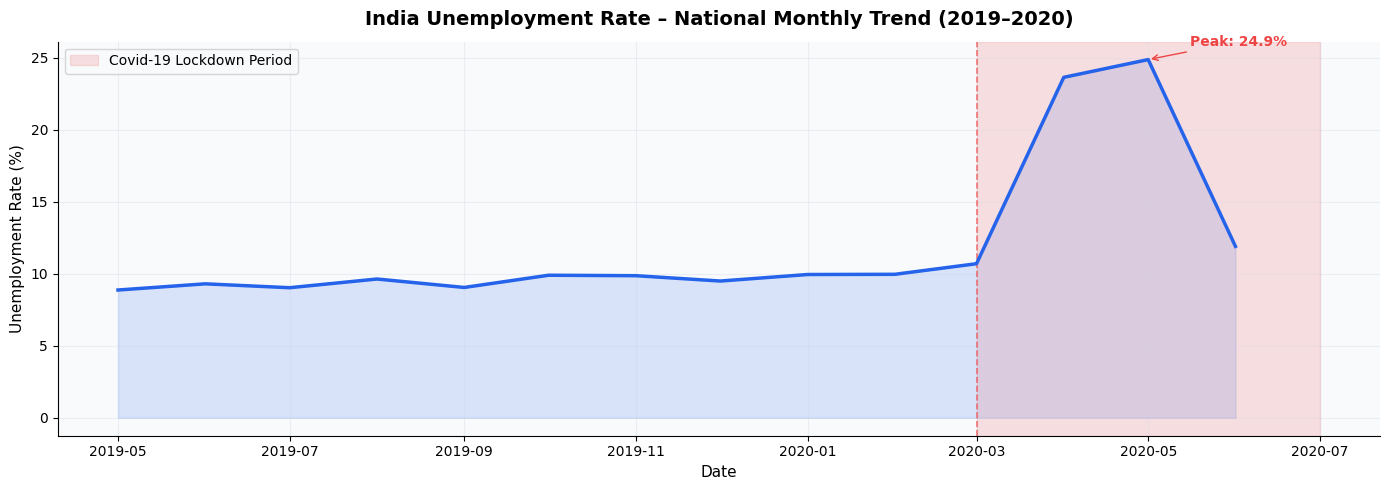

In [ ]:
national = (df.groupby('YearMonth')['Estimated Unemployment Rate (%)']
              .mean().reset_index())
national['Date'] = national['YearMonth'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_facecolor(BG)

# Line + shaded area
ax.plot(national['Date'], national['Estimated Unemployment Rate (%)'],
        color=BLUE, linewidth=2.5, zorder=3)
ax.fill_between(national['Date'], national['Estimated Unemployment Rate (%)'],
                alpha=0.15, color=BLUE)

# Covid shading
ax.axvspan(covid_start, covid_end, alpha=0.15, color=RED, label='Covid-19 Lockdown Period')
ax.axvline(covid_start, color=RED, linestyle='--', linewidth=1.2, alpha=0.7)

# Annotate peak
peak_row = national.loc[national['Estimated Unemployment Rate (%)'].idxmax()]
ax.annotate(
    f"Peak: {peak_row['Estimated Unemployment Rate (%)']:.1f}%",
    xy=(peak_row['Date'], peak_row['Estimated Unemployment Rate (%)']),
    xytext=(30, 10), textcoords='offset points',
    fontsize=10, fontweight='bold', color=RED,
    arrowprops=dict(arrowstyle='->', color=RED)
)

ax.set_title('India Unemployment Rate – National Monthly Trend (2019–2020)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Unemployment Rate (%)', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig1_national_trend.png', dpi=150, bbox_inches='tight')
plt.show()


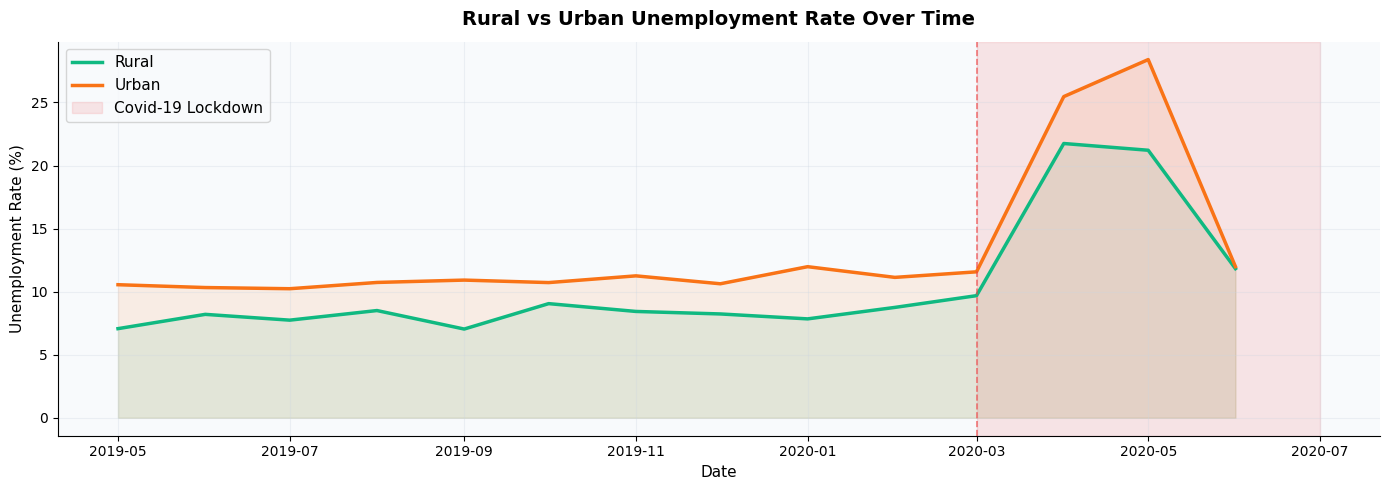

In [ ]:
area = (df.groupby(['YearMonth', 'Area'])['Estimated Unemployment Rate (%)']
          .mean().reset_index())
area['Date'] = area['YearMonth'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_facecolor(BG)

for area_type, color in [('Rural', GREEN), ('Urban', ORANGE)]:
    sub = area[area['Area'] == area_type]
    ax.plot(sub['Date'], sub['Estimated Unemployment Rate (%)'],
            color=color, linewidth=2.5, label=area_type)
    ax.fill_between(sub['Date'], sub['Estimated Unemployment Rate (%)'],
                    alpha=0.1, color=color)

ax.axvspan(covid_start, covid_end, alpha=0.12, color=RED, label='Covid-19 Lockdown')
ax.axvline(covid_start, color=RED, linestyle='--', linewidth=1.2, alpha=0.7)

ax.set_title('Rural vs Urban Unemployment Rate Over Time', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Unemployment Rate (%)', fontsize=11)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('fig2_rural_urban.png', dpi=150, bbox_inches='tight')
plt.show()


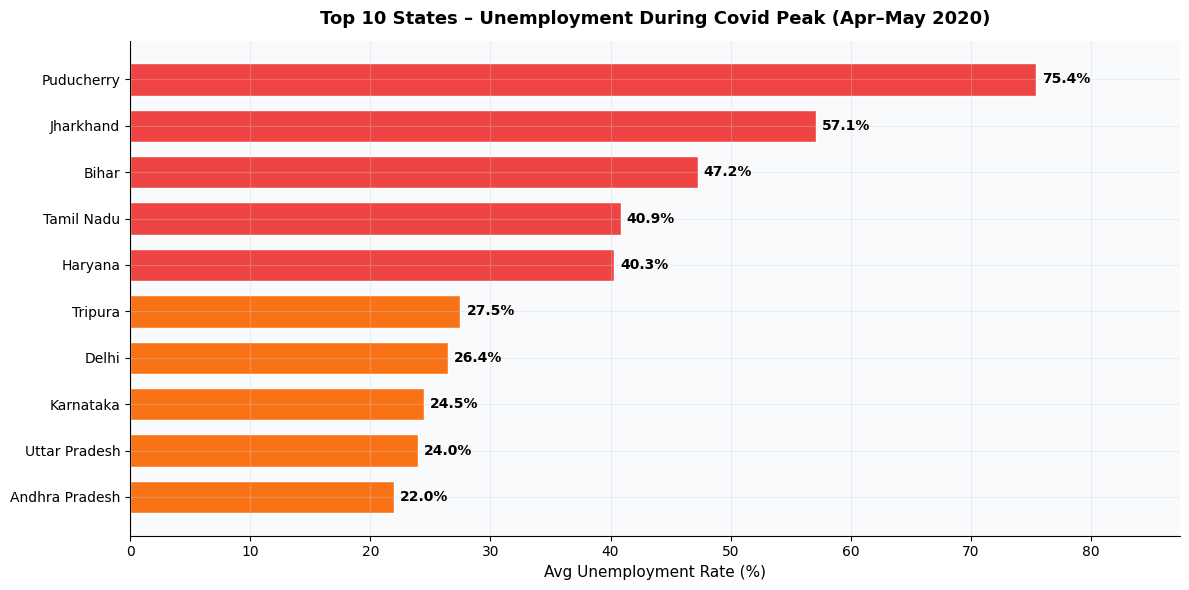

In [ ]:
state_covid = (covid_peak.groupby('Region')['Estimated Unemployment Rate (%)']
               .mean().sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_facecolor(BG)

colors = [RED if v > 30 else ORANGE if v > 20 else BLUE for v in state_covid.values]
bars = ax.barh(state_covid.index[::-1], state_covid.values[::-1],
               color=colors[::-1], edgecolor='white', height=0.7)

for bar, val in zip(bars, state_covid.values[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.set_title('Top 10 States – Unemployment During Covid Peak (Apr–May 2020)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Avg Unemployment Rate (%)', fontsize=11)
ax.set_xlim(0, state_covid.max() + 12)
plt.tight_layout()
plt.savefig('fig3_top_states_covid.png', dpi=150, bbox_inches='tight')
plt.show()


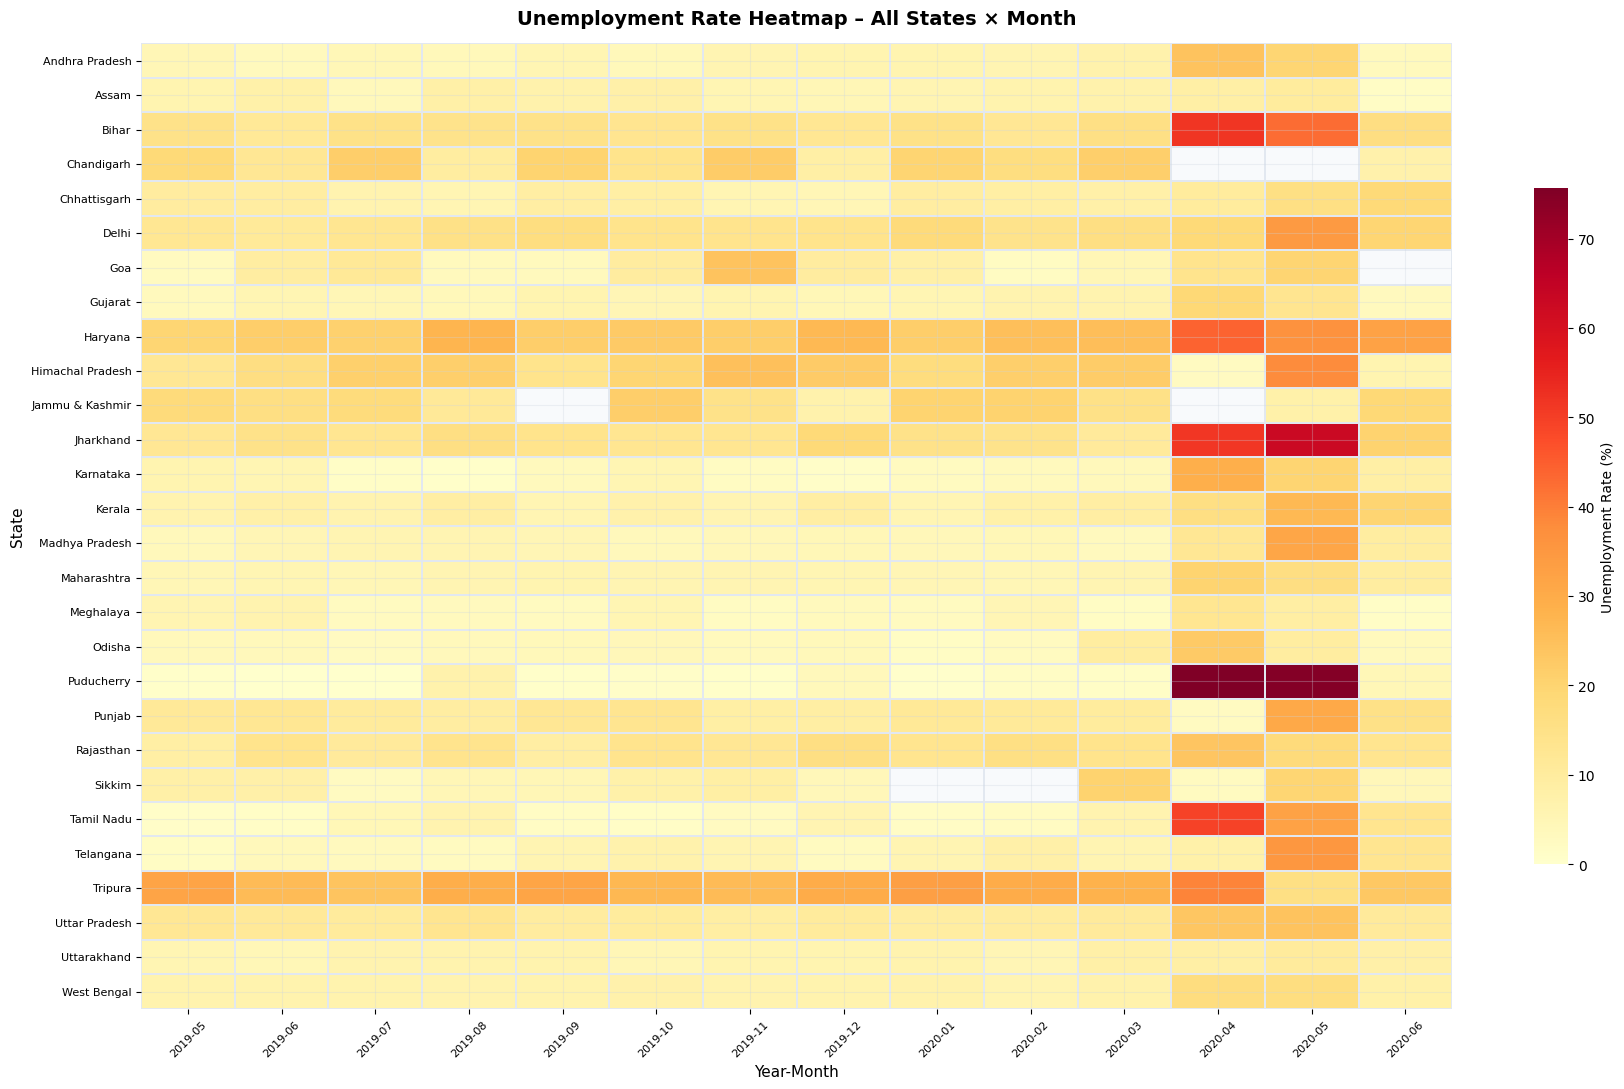

In [ ]:
pivot = df.pivot_table(
    index='Region',
    columns='YearMonth',
    values='Estimated Unemployment Rate (%)',
    aggfunc='mean'
)
pivot.columns = [str(c) for c in pivot.columns]

fig, ax = plt.subplots(figsize=(18, 11))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax,
            linewidths=0.3, linecolor='#e2e8f0',
            cbar_kws={'label': 'Unemployment Rate (%)', 'shrink': 0.7})

ax.set_title('Unemployment Rate Heatmap – All States × Month',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Year-Month', fontsize=11)
ax.set_ylabel('State', fontsize=11)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig('fig4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


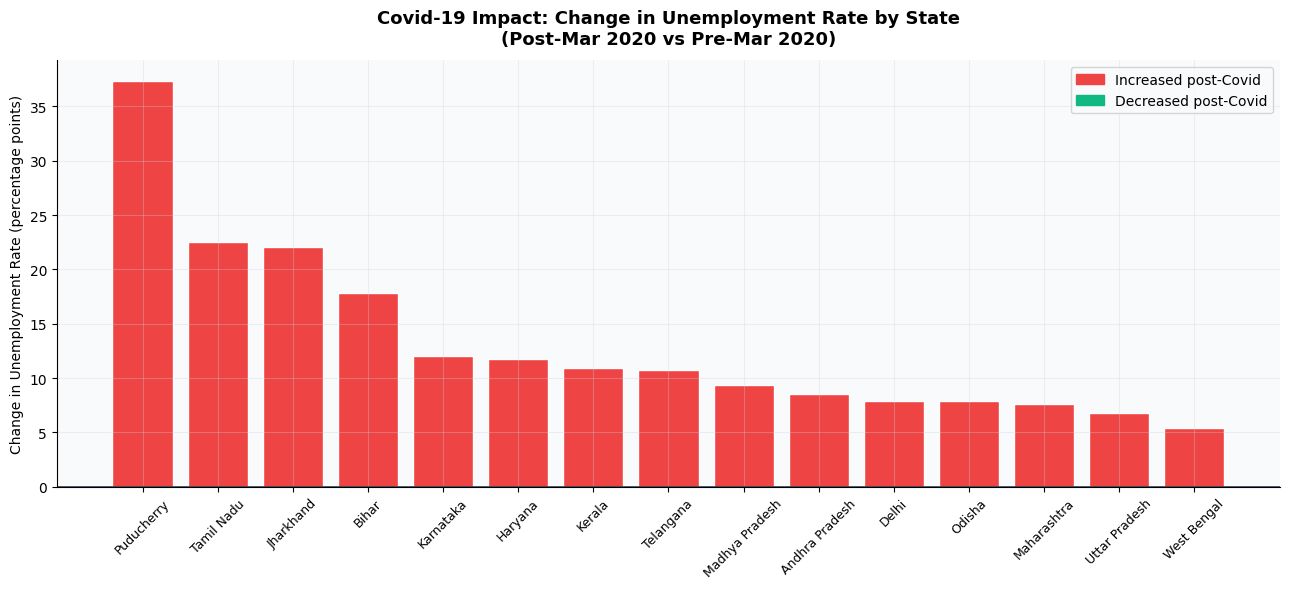

In [ ]:
pre_avg  = (df[df['Date'] < '2020-03-01']
            .groupby('Region')['Estimated Unemployment Rate (%)'].mean())
post_avg = (df[df['Date'] >= '2020-03-01']
            .groupby('Region')['Estimated Unemployment Rate (%)'].mean())

diff = (post_avg - pre_avg).dropna().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(13, 6))
ax.set_facecolor(BG)

bar_colors = [RED if d > 0 else GREEN for d in diff.values]
ax.bar(diff.index, diff.values, color=bar_colors, edgecolor='white')
ax.axhline(0, color='#334155', linewidth=1.2)

ax.set_title('Covid-19 Impact: Change in Unemployment Rate by State\n(Post-Mar 2020 vs Pre-Mar 2020)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Change in Unemployment Rate (percentage points)', fontsize=10)
ax.tick_params(axis='x', rotation=45, labelsize=9)

red_patch   = mpatches.Patch(color=RED,   label='Increased post-Covid')
green_patch = mpatches.Patch(color=GREEN, label='Decreased post-Covid')
ax.legend(handles=[red_patch, green_patch], fontsize=10)
plt.tight_layout()
plt.savefig('fig5_covid_impact.png', dpi=150, bbox_inches='tight')
plt.show()


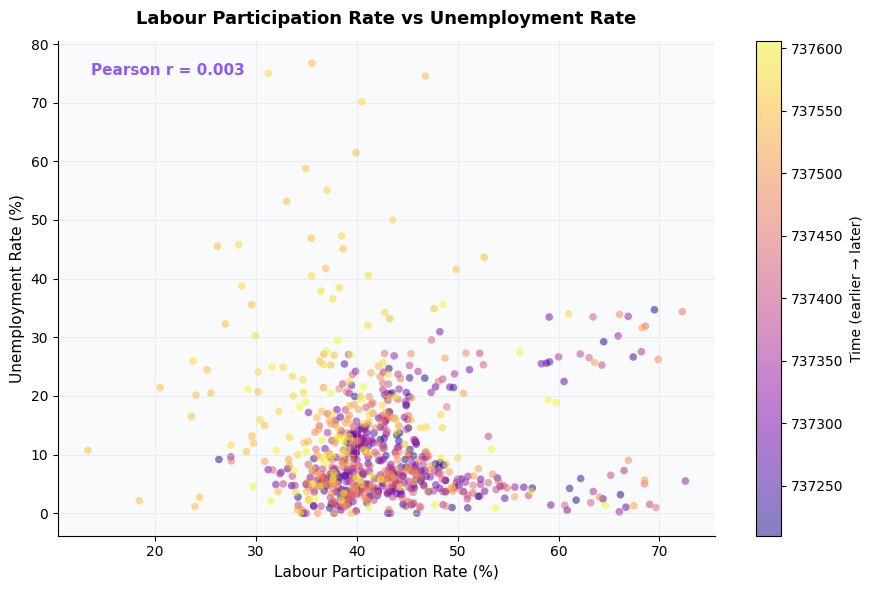

In [ ]:
corr = df[['Estimated Labour Participation Rate (%)',
           'Estimated Unemployment Rate (%)']].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(9, 6))
ax.set_facecolor(BG)

sc = ax.scatter(
    df['Estimated Labour Participation Rate (%)'],
    df['Estimated Unemployment Rate (%)'],
    c=df['Date'].map(pd.Timestamp.toordinal),
    cmap='plasma', alpha=0.5, s=30, edgecolors='none'
)
plt.colorbar(sc, ax=ax, label='Time (earlier → later)')

ax.text(0.05, 0.93, f'Pearson r = {corr:.3f}',
        transform=ax.transAxes, fontsize=11, fontweight='bold', color=PURPLE)
ax.set_xlabel('Labour Participation Rate (%)', fontsize=11)
ax.set_ylabel('Unemployment Rate (%)', fontsize=11)
ax.set_title('Labour Participation Rate vs Unemployment Rate',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('fig6_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
print("=" * 55)
print("      UNEMPLOYMENT ANALYSIS – FINAL SUMMARY")
print("=" * 55)
print(f"\n Period     : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f" Records    : {len(df)}")
print(f" States/UTs : {df['Region'].nunique()}")

print(f"\  Overall Avg Unemployment    : {df['Estimated Unemployment Rate (%)'].mean():.2f}%")
print(f" Pre-Covid  Avg (< Mar 2020) : {pre_covid['Estimated Unemployment Rate (%)'].mean():.2f}%")
print(f" Covid Peak Avg (Apr–May 20) : {covid_peak['Estimated Unemployment Rate (%)'].mean():.2f}%")
print(f" Post-Covid Avg (Jun 2020+)  : {post_covid['Estimated Unemployment Rate (%)'].mean():.2f}%")

peak = df.loc[df['Estimated Unemployment Rate (%)'].idxmax()]
print(f"\n Highest : {peak['Estimated Unemployment Rate (%)']:.2f}%  →  {peak['Region']}  ({peak['Date'].strftime('%B %Y')})")
print(f"\n Rural Avg : {df[df['Area']=='Rural']['Estimated Unemployment Rate (%)'].mean():.2f}%")
print(f"  Urban Avg : {df[df['Area']=='Urban']['Estimated Unemployment Rate (%)'].mean():.2f}%")
print(f"\n Labour Participation Correlation : {corr:.3f}")

print("\n KEY POLICY INSIGHTS:")
print("   1. Covid-19 caused a 2.5x spike in unemployment (Apr–May 2020)")
print("   2. Urban unemployment is structurally higher than rural")
print("   3. Puducherry, Jharkhand & Bihar were hardest hit during lockdown")
print("   4. Higher labour participation correlates with lower unemployment")
print("   5. Most states showed recovery by June 2020")
print("=" * 55)

      UNEMPLOYMENT ANALYSIS – FINAL SUMMARY

 Period     : 2019-05-31 → 2020-06-30
 Records    : 740
 States/UTs : 28
\  Overall Avg Unemployment    : 11.79%
 Pre-Covid  Avg (< Mar 2020) : 9.51%
 Covid Peak Avg (Apr–May 20) : 24.26%
 Post-Covid Avg (Jun 2020+)  : 11.90%

 Highest : 76.74%  →  Puducherry  (April 2020)

 Rural Avg : 10.32%
  Urban Avg : 13.17%

 Labour Participation Correlation : 0.003

 KEY POLICY INSIGHTS:
   1. Covid-19 caused a 2.5x spike in unemployment (Apr–May 2020)
   2. Urban unemployment is structurally higher than rural
   3. Puducherry, Jharkhand & Bihar were hardest hit during lockdown
   4. Higher labour participation correlates with lower unemployment
   5. Most states showed recovery by June 2020
